# Plot Fig5 related to MOFA analysis in CD4 Naive cells of preRA Teaseq
- plot figures from MOFA model results
- analyze Factor 1

# set up


In [108]:
# import libraries
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("Matrix")
quiet_library("viridis")
quiet_library("MOFA2")
quiet_library("data.table")
quiet_library("jsonlite")
quiet_library("parallel")
quiet_library("ggpubr")
quiet_library("ComplexHeatmap")
quiet_library("hise")

In [2]:
# define file path
fig_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/figures"
data_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243"
meta_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/meta_data"
output_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/output_results/MOFA"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "PreRA_teaseq_MOFA_cd4na"

In [3]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
con_ari_colors <- c("#5AAA46", "#F59F00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

# load MOFA trained model and perform downstream analysis


In [56]:
# load the trained model
model <- load_model(file.path(output_path, "mofa_preRA_cd4_rna_adt_olink_tf_pseudobulk_model_09202023.hdf5"))

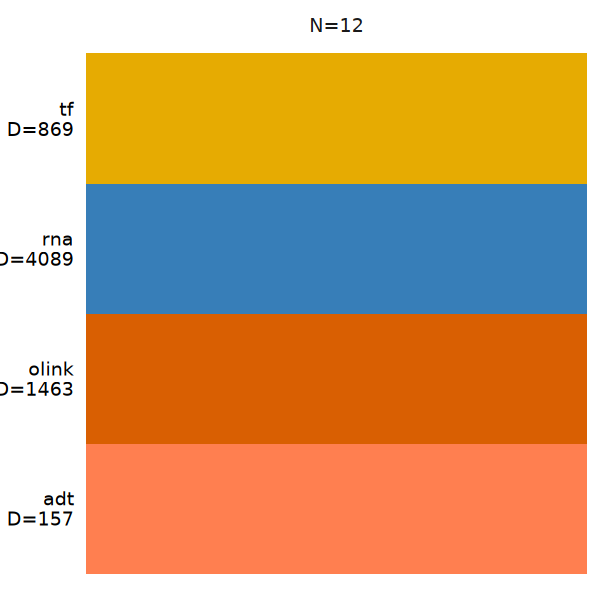

In [57]:
plot_data_overview(model)
ggsave(file.path(fig_path, paste0(proj_name, "_data_overview.png")),
  width = 4, height = 4
)

In [58]:
# add metadata to the model
meta_data <- meta_data %>%
  filter(sample != "BR2024") %>%
  mutate(status = factor(recode(cohort, "at_risk" = "ARI", "healthy" = "CON2"),
    levels = c("CON2", "ARI")
  ))
meta_data

sample,sample.sampleKitGuid,subject.biologicalSex,cohort.cohortGuid,age,rheumatoid_factor_iga,rheumatoid_factor_igm,anti_ccp3,cohort,status
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
CU1005,KT00060,Female,CU1,40,0.25,0.25,195,at_risk,ARI
CU1013,KT00065,Female,CU1,61,NA,NA,262,at_risk,ARI
CU1019,KT00067,Female,CU1,74,0.25,0.25,30,at_risk,ARI
CU1022,KT00073,Female,CU1,71,11.41,3.09,64,at_risk,ARI
CU1002,KT00096,Female,CU1,79,0.25,4.03,22,at_risk,ARI
CU1004,KT00212,Female,CU1,33,0.25,1.38,28,at_risk,ARI
CU1009,KT00219,Female,CU1,57,0.25,26.85,91,at_risk,ARI
BR1019,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2
BR1031,KT00332,Female,BR1,33,NA,NA,NA,healthy,CON2


In [59]:
# add metadata to the model
samples_metadata(model) <- meta_data

In [60]:
# extract the facot
factors_values <- get_factors(model,
  factors = "all",
  as.data.frame = TRUE
) %>%
  as_tibble() %>%
  left_join(samples_metadata(model), by = "sample") %>%
  mutate(cohort = factor(cohort, levels = c("healthy", "at_risk")))
head(factors_values)

sample,factor,value,group.x,sample.sampleKitGuid,subject.biologicalSex,cohort.cohortGuid,age,rheumatoid_factor_iga,rheumatoid_factor_igm,anti_ccp3,cohort,status,group.y
<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<chr>
BR1019,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group
BR1031,Factor1,-1.3124271,single_group,KT00332,Female,BR1,33,NA,NA,NA,healthy,CON2,single_group
BR2018,Factor1,0.3584153,single_group,KT00569,Female,BR2,63,NA,NA,0,healthy,CON2,single_group
BR2029,Factor1,-1.3654777,single_group,KT00561,Female,BR2,58,NA,NA,0,healthy,CON2,single_group
BR2034,Factor1,-1.3273368,single_group,KT00501,Female,BR2,63,NA,NA,0,healthy,CON2,single_group
CU1002,Factor1,0.8311946,single_group,KT00096,Female,CU1,79,0.25,4.03,22,at_risk,ARI,single_group


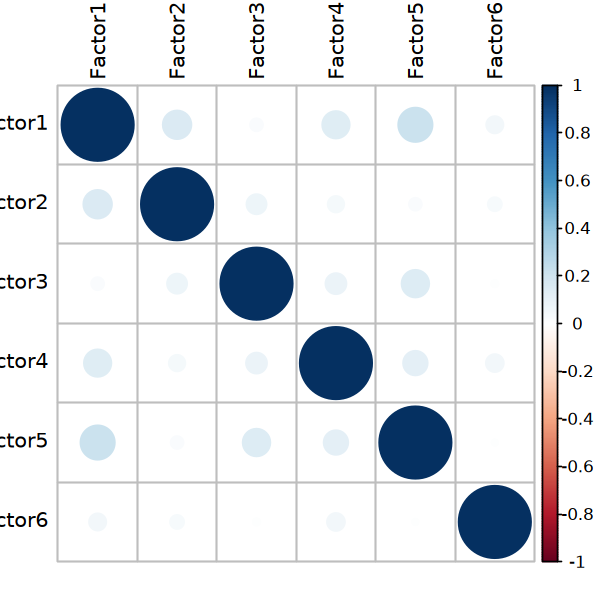

In [61]:
# check if the factors are correlated with each other
plot_factor_cor(model)

In [66]:
# Variance explained for every factor in per view and group
variance_exp <- model@cache$variance_explained$r2_per_factor[[1]] %>% as_tibble(rownames = "factor")
variance_exp %>% head()

factor,adt,olink,rna,tf
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Factor1,15.226354,2.7654419,29.349644,9.513926
Factor2,5.348212,0.4106226,6.815339,32.517234
Factor3,13.115709,4.1711978,11.563944,2.605630
Factor4,10.457987,0.4470810,6.138395,12.452194
Factor5,6.409601,9.4171286,5.780365,1.524211
Factor6,4.630891,1.6330288,4.139567,5.423212


In [68]:
# save the virance explained table
variance_exp %>% write_csv(file.path(output_path, "MOFA_CD4na_factors_variance_explained.csv"))

### plot fig 5B

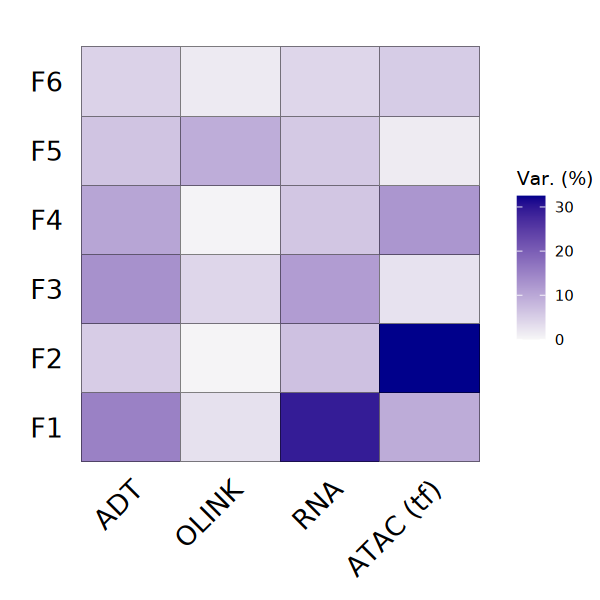

In [70]:
# plot the variance in each modality explained by the mofa factors
p1 <- plot_variance_explained(model, x = "view", y = "factor") +
  scale_x_discrete(labels = c(
    "adt" = "ADT", "olink" = "OLINK",
    "rna" = "RNA", "tf" = "ATAC (tf)"
  )) +
  scale_y_discrete(labels = c(
    "Factor1" = "F1", "Factor2" = "F2", "Factor3" = "F3",
    "Factor4" = "F4", "Factor5" = "F5", "Factor6" = "F6"
  )) +
  theme(
    axis.text.x = element_text(
      size = 16, angle = 45, hjust = 1
    ),
    axis.text.y = element_text(
      size = 16
    )
  )
p1
ggsave(file.path(fig_path, paste0(proj_name, "_variance_decomposition_factor_heatmap.pdf")), width = 3, height = 3)

In [73]:
# run glm ARI vs healthy
glm_test <- function(data, formula) {
  glm_res <- broom::tidy(stats::glm(as.formula(formula), data = data))
  return(glm_res)
}
stats_glm <- factors_values %>%
  mutate(status = factor(status, levels = c("CON2", "ARI"))) %>%
  group_by(factor) %>%
  group_modify(~ glm_test(.x, formula = "value ~ status + age"))
stats_glm %>%
  filter(term != "(Intercept)") %>%
  rstatix::adjust_pvalue(p.col = "p.value", method = "BH") %>%
  arrange(p.value.adj) %>%
  filter(term == "statusARI")
# factor 1 significant different between ARI and healthy

factor,term,estimate,std.error,statistic,p.value,p.value.adj
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Factor1,statusARI,1.47774756,0.3414606,4.3277252,0.00191145,0.00382290
Factor4,statusARI,0.39376285,0.1726967,2.2800828,0.04855591,0.09711182
Factor3,statusARI,0.24060757,0.2303998,1.0443047,0.32358154,0.32358154
Factor2,statusARI,-0.24974248,0.2922364,-0.8545906,0.41494628,0.51278988
Factor5,statusARI,0.05727685,0.1661356,0.3447597,0.73819464,0.73819464
Factor6,statusARI,-0.13965937,0.1801241,-0.7753507,0.45802002,0.89344152


### plot fig 5C

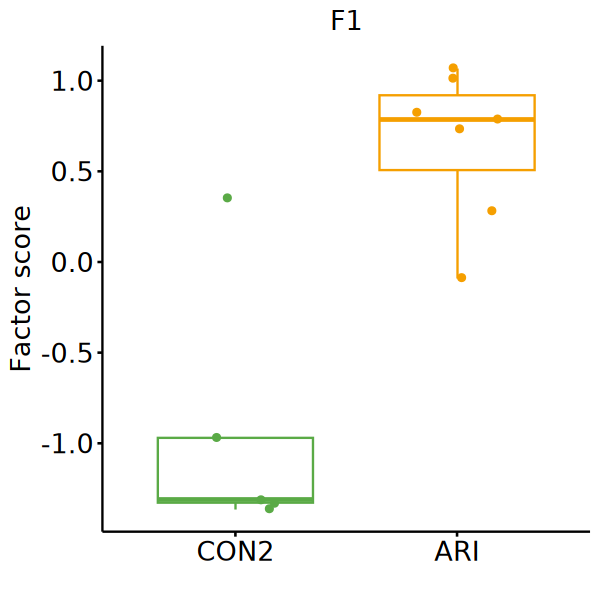

In [75]:
# plot factor1
factors_values %>%
  filter(factor == "Factor1") %>%
  ggpubr::ggboxplot(
    x = "status", y = "value", add = "jitter",
    color = "status", palette = con_ari_colors
  ) +
  # ggpubr::stat_compare_means() +
  ggtitle("F1") +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 16),
    axis.text.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.text.y = element_text(size = 16)
  ) + xlab("") + ylab("Factor score")

ggsave(file.path(fig_path, paste0(proj_name, "_factor1_status.pdf")), width = 3, height = 3)

### plot fig S11B

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


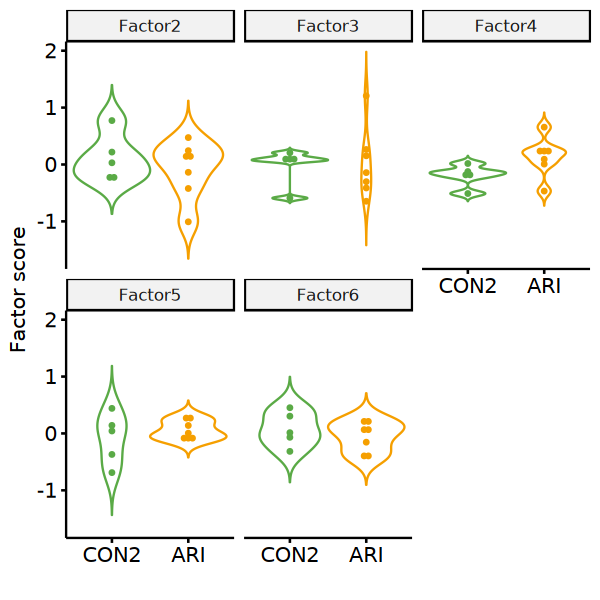

In [77]:
# plot other factors for comparison
factors_values %>%
  filter(factor != "Factor1") %>%
  ggpubr::ggviolin(
    x = "status", y = "value", add = "dotplot",
    color = "status", palette = con_ari_colors
  ) +
  theme(legend.position = "none", plot.title = element_text(hjust = 0.5)) + xlab("") + ylab("Factor score") + facet_wrap(vars(factor))
ggsave(file.path(fig_path, paste0(proj_name, "_notsig_factor_status.pdf")), width = 4, height = 4)

## analyze Factor1


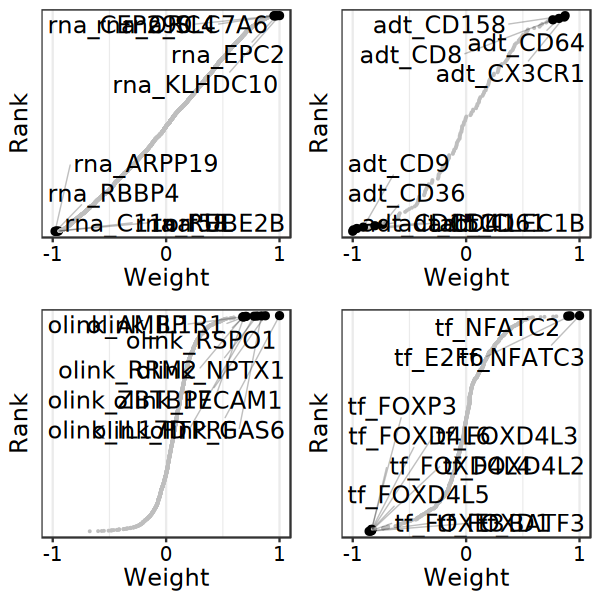

In [78]:
# plot the top features of foctor1
factor <- 1
p1 <- plot_weights(model,
  view = "rna",
  factor = factor,
  nfeatures = 10, # Number of features to highlight
  scale = T, # Scale weights from -1 to 1
  abs = F # Take the absolute value?
)
p2 <- plot_weights(model,
  view = "adt",
  factor = factor,
  nfeatures = 10, # Number of features to highlight
  scale = T, # Scale weights from -1 to 1
  abs = F # Take the absolute value?
)
p3 <- plot_weights(model,
  view = "olink",
  factor = factor,
  nfeatures = 10, # Number of features to highlight
  scale = T, # Scale weights from -1 to 1
  abs = F # Take the absolute value?
)
p4 <- plot_weights(model,
  view = "tf",
  factor = factor,
  nfeatures = 10, # Number of features to highlightß
  scale = T, # Scale weights from -1 to 1
  abs = F # Take the absolute value?
)
cowplot::plot_grid(p1, p2, p3, p4, nrow = 2)
ggsave(file.path(fig_path, paste0(proj_name, "_cd4na_factor1_weights.png")),
  width = 12, height = 8
)

In [79]:
# extract the weight of the models
weight <- get_weights(model, views = "all", as.data.frame = TRUE) %>%
  mutate(direction = if_else(value > 0, "up", "down"))
weight %>% head()

,feature,factor,value,view,direction
,<fct>,<fct>,<dbl>,<fct>,<chr>
1,adt_CD86,Factor1,-0.04790149,adt,down
2,adt_CD274,Factor1,-0.41834556,adt,down
3,adt_CD270,Factor1,0.31398610,adt,up
4,adt_CD155,Factor1,-0.08834319,adt,down
5,adt_CD112,Factor1,-0.30586839,adt,down
6,adt_CD47,Factor1,-0.60329632,adt,down


In [80]:
# save feature weights
weight %>% write_tsv(file.path(output_path, "Mofa_preRA_cd4na_09202023_factor_weights.tsv"))

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


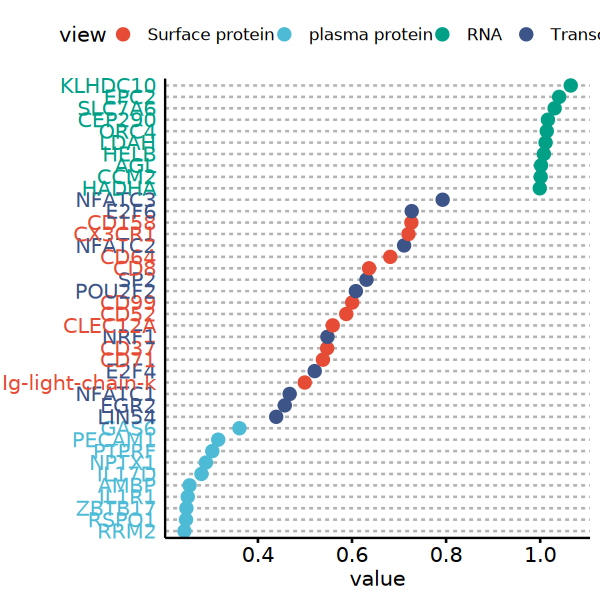

In [81]:
# plot dot plot of top features
f1_top_weights <- weight %>%
  filter(factor == "Factor1") %>%
  group_by(view) %>%
  slice_max(order_by = value, n = 10) %>%
  arrange(desc(value)) %>%
  mutate(
    view = recode(view,
      "rna" = "RNA", "tf" = "Transcription Factor",
      "adt" = "Surface protein", "olink" = "plasma protein"
    ),
    feature = str_split(feature, pattern = "_", simplify = TRUE)[, 2]
  )
ggdotchart(f1_top_weights,
  x = "feature", y = "value",
  color = "view", # Color by groups
  palette = npg_color, # Custom color palette
  sorting = "descending", # Sort value in descending order
  rotate = TRUE, # Rotate vertically
  dot.size = 3, # Large dot size
  y.text.col = TRUE, # Color y text by groups
  ggtheme = theme_pubr() # ggplot2 theme
) +
  theme_cleveland()
ggsave(file.path(fig_path, paste0(proj_name, "_cd4na_factor1_weights_dotplot.pdf")),
  width = 6, height = 8
)

### check TF acitivity associated with factor 1


In [82]:
# plot dot plot of top features
f1_tf_weights <- weight %>%
  filter(factor == "Factor1" & view == "tf") %>%
  group_by(direction) %>%
  arrange(desc(value)) %>%
  mutate(`Transcription factors` = str_remove(if_else(feature %in% c("tf_NFATC3", "tf_NFATC2", "tf_NFATC1", "tf_NFATC4"),
    "NFATs", "Other TFs"
  ), "tf_")) %>%
  mutate(
    view = recode(view,
      "rna" = "RNA", "tf" = "Transcription Factor",
      "adt" = "Surface protein", "olink" = "plasma protein"
    ),
    feature = str_split(feature, pattern = "_", simplify = TRUE)[, 2]
  ) %>%
  mutate(
    `Transcription Factor Activity` = factor(if_else(direction == "up", "Enriched in ARI", "Enriched in Controls"),
      levels = c("Enriched in Controls", "Enriched in ARI")
    ),
    rank = rank(value, )
  )
f1_tf_weights %>% head()
# f1_tf_weights%>%ggplot(aes(x=value, y=))

feature,factor,value,view,direction,Transcription factors,Transcription Factor Activity,rank
<chr>,<fct>,<dbl>,<fct>,<chr>,<chr>,<fct>,<dbl>
NFATC3,Factor1,0.7926583,Transcription Factor,up,NFATs,Enriched in ARI,417
E2F6,Factor1,0.7268859,Transcription Factor,up,Other TFs,Enriched in ARI,416
NFATC2,Factor1,0.7107052,Transcription Factor,up,NFATs,Enriched in ARI,415
SP2,Factor1,0.6306949,Transcription Factor,up,Other TFs,Enriched in ARI,414
POU2F2,Factor1,0.6081893,Transcription Factor,up,Other TFs,Enriched in ARI,413
NRF1,Factor1,0.5477583,Transcription Factor,up,Other TFs,Enriched in ARI,412


### output table S36 TF weight

In [87]:
# output table S36 TF weight
f1_top_tf_weights %>%
  rename("feature" = "TF", "value" = "weight associated with Factor1") %>%
  write_csv(file.path(output_path, "MOFA_CD4na_TF_weights_F1.csv"))

#### plot fig 5E


Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


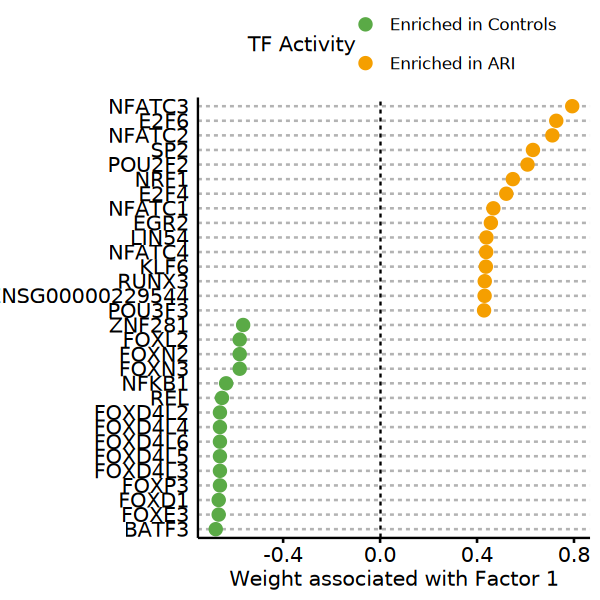

In [83]:
# plot dot plot of top features
options(repr.plot.width = 5, repr.plot.height = 5)
f1_top_tf_weights <- weight %>%
  filter(factor == "Factor1" & view == "tf") %>%
  group_by(direction) %>%
  slice_max(order_by = abs(value), n = 15) %>%
  arrange(desc(value)) %>%
  mutate(`Transcription factors` = str_remove(if_else(feature %in% c("tf_NFATC3", "tf_NFATC2", "tf_NFATC1", "tf_NFATC4"),
    "NFATs", "Other TFs"
  ), "tf_")) %>%
  mutate(
    view = recode(view,
      "rna" = "RNA", "tf" = "Transcription Factor",
      "adt" = "Surface protein", "olink" = "plasma protein"
    ),
    feature = str_split(feature, pattern = "_", simplify = TRUE)[, 2]
  ) %>%
  mutate(`TF Activity` = factor(if_else(direction == "up", "Enriched in ARI", "Enriched in Controls"),
    levels = c("Enriched in Controls", "Enriched in ARI")
  ))

ggdotchart(f1_top_tf_weights,
  x = "feature", y = "value",
  color = "TF Activity", # Color by groups
  palette = con_ari_colors, # Custom color palette
  sorting = "descending", # Sort value in descending order
  rotate = TRUE, # Rotate vertically
  dot.size = 3, # Large dot size
  y.text.col = TRUE, # Color y text by groups
  # ggtheme = theme_bw(),                    # ggplot2 theme
  ylab = "Weight associated with Factor 1"
) +
  theme_cleveland() + geom_hline(yintercept = 0, linetype = 2) +
  theme(
    legend.position = "top", legend.box = "vertical", legend.margin = margin(),
    axis.text.y = element_text(color = "black")
  ) + guides(color = guide_legend(nrow = 2))
ggsave(file.path(fig_path, paste0(proj_name, "_cd4na_factor1_tf_weights_dotplot.pdf")),
  width = 5, height = 5
)

### plot fig S11C

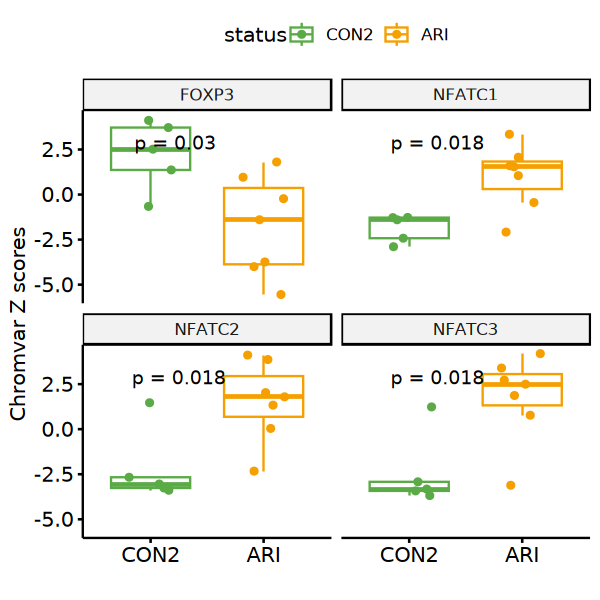

In [88]:
p1 <- chromvar_tf %>%
  mutate(status = factor(if_else(str_detect(subject_id, "CU"), "ARI", "CON2"),
    levels = c("CON2", "ARI")
  )) %>%
  filter(tf %in% c("NFATC3", "NFATC1", "NFATC2", "FOXP3")) %>%
  ggpubr::ggboxplot(
    x = "status", y = "value", palette = con_ari_colors,
    ylab = "Chromvar Z scores", xlab = "",
    color = "status", add = "jitter"
  ) +
  ggpubr::stat_compare_means(
    method = "wilcox.test", label.y = 2.5,
    aes(label = paste0("p = ", after_stat(p.format)))
  ) +
  facet_wrap(vars(tf), ncol = 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, "_NFATs_Chromvar_zscores.pdf")), width = 4, height = 4)

In [91]:
factor1_tf <- weight %>%
  filter(factor == "Factor1" & view == "tf") %>%
  mutate(direction = if_else(value > 0, "healthy", "at-risk")) %>%
  arrange(desc(abs(value))) %>%
  filter(!str_detect(feature, "ENSG|DUX"))
# factor1_tf %>% group_by(direction) %>% slice_max(order_by = abs(value),n = 60)

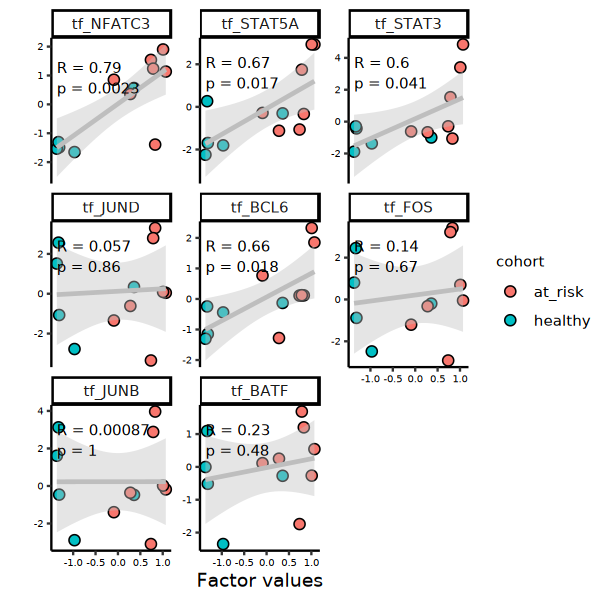

In [92]:
plot_data_scatter(model,
  factor = 1,
  features = c(
    "tf_NFATC3", "tf_STAT5A", "tf_STAT3", "tf_JUND", "tf_BCL6", "tf_FOS", "tf_JUNB",
    "tf_BATF"
  ),
  view = "tf", color_by = "cohort"
)
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_tf_correlation_cohort_nfat_partners.png")),
  width = 8, height = 4
)

In [93]:
# get factor 1 and tf data
f1_tf_data <- get_data(model,
  as.data.frame = TRUE,
  view = "tf"
) %>%
  mutate(feature = str_remove(feature, "tf_")) %>%
  dplyr::rename("TF_activity" = "value") %>%
  left_join(filter(factors_values, factor == "Factor1") %>%
    dplyr::rename("Factor_score" = "value"), by = "sample")
f1_tf_data %>% head()

,view,group,feature,sample,TF_activity,factor,Factor_score,group.x,sample.sampleKitGuid,subject.biologicalSex,cohort.cohortGuid,age,rheumatoid_factor_iga,rheumatoid_factor_igm,anti_ccp3,cohort,status,group.y
,<fct>,<fct>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<chr>
1,tf,single_group,TFAP2B,BR1019,0.001909104,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group
2,tf,single_group,TFAP2D,BR1019,-0.728895671,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group
3,tf,single_group,TFAP2C,BR1019,0.087349007,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group
4,tf,single_group,TFAP2E,BR1019,-0.164269077,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group
5,tf,single_group,TFAP2A,BR1019,-0.012176022,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group
6,tf,single_group,ARID3A,BR1019,-1.169052265,Factor1,-0.9698831,single_group,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2,single_group


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


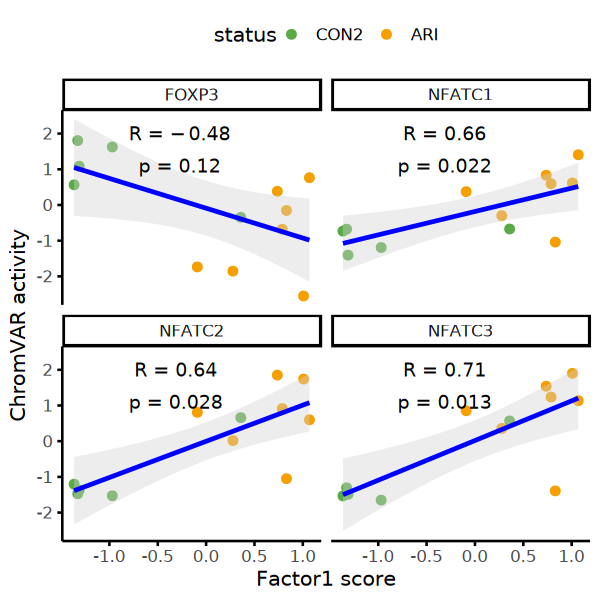

In [94]:
options(repr.plot.width = 5, repr.plot.height = 5)
f1_tf_data_nfat <- f1_tf_data %>% filter(feature %in% c("FOXP3", "NFATC1", "NFATC2", "NFATC3"))
ggpubr::ggscatter(f1_tf_data_nfat,
  x = "Factor_score", y = "TF_activity",
  xlab = "Factor1 score", ylab = "ChromVAR activity",
  color = "status", facet.by = "feature", palette = con_ari_colors,
  add = "reg.line", # Add regressin line
  add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
  conf.int = TRUE, # Add confidence interval
  cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
  cor.coeff.args = list(method = "spearman", label.x = -0.8, label.y = 1.5, label.sep = "\n"),
  ggtheme = theme_classic2()
) + scale_fill_manual(values = con_ari_colors) + theme(legend.position = "top")
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_tf_correlation_cohort_nfat_foxp3.pdf")),
  width = 5, height = 5
)

## check RNA


In [95]:
factor1_rna <- weight %>%
  filter(factor == "Factor1" & view == "rna") %>%
  mutate(direction = if_else(value > 0, "healthy", "at-risk")) %>%
  arrange(desc(abs(value)))
factor1_rna_sel <- factor1_rna %>%
  group_by(direction) %>%
  slice_max(order_by = abs(value), n = 50)

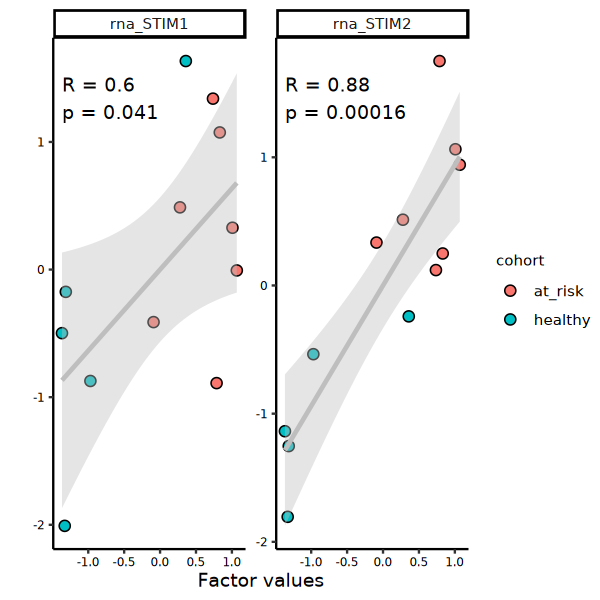

In [99]:
p1 <- plot_data_scatter(model,
  factor = 1,
  features = c("rna_STIM1", "rna_STIM2"),
  view = "rna", color_by = "cohort"
)
p1
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_rna_correlation_Ca_channel.png")),
  width = 6, height = 3
)

feature,factor,value,view,direction
<fct>,<fct>,<dbl>,<fct>,<chr>
rna_VAV1,Factor1,0.9908883,rna,healthy
rna_GRAP2,Factor1,0.9441940,rna,healthy
rna_NFATC2,Factor1,0.9216880,rna,healthy
rna_GRB2,Factor1,0.9065119,rna,healthy
rna_CARD11,Factor1,0.8701368,rna,healthy
rna_NFAT5,Factor1,0.8658133,rna,healthy
rna_CBL,Factor1,0.8442979,rna,healthy
rna_LCK,Factor1,0.7968728,rna,healthy
rna_IKBKB,Factor1,0.7816963,rna,healthy


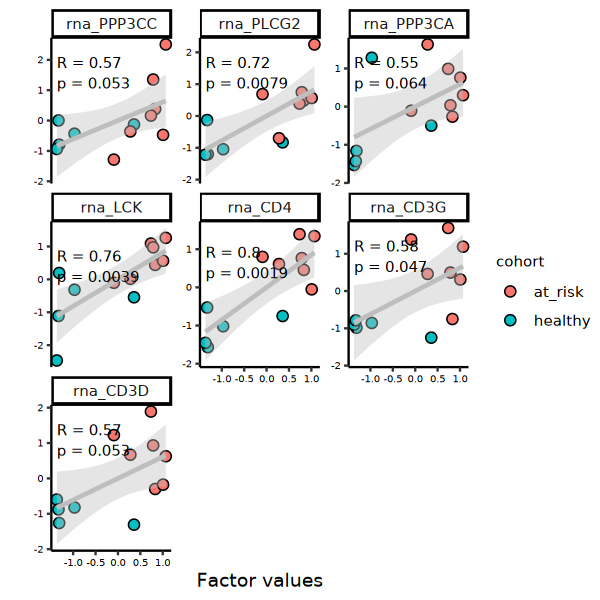

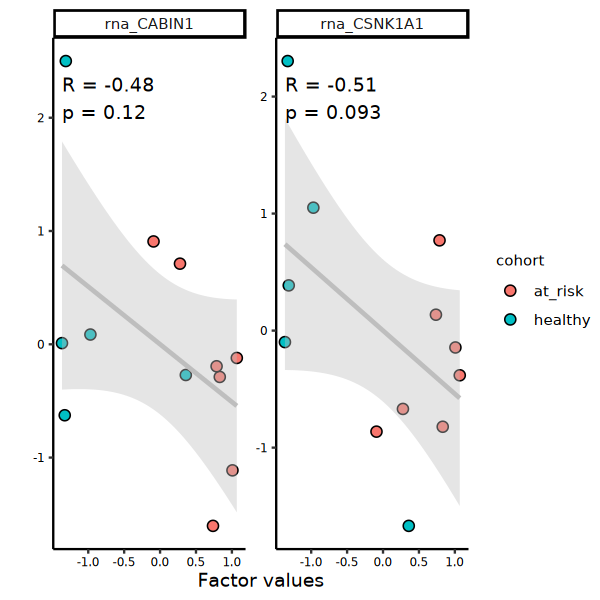

In [100]:
# plot ca2+ related gene expression
tcr_gene <- paste0("rna_", c(
  "VAV1", "GRB2", "GRAP2", "NFATC2", "NFAT5", "CBL",
  "CARD11", "LCK", "IKBKB", "CD4", "PIK3R1", "MALT1",
  "RAF1", "SOS1", "NCK2", "CD3G", "LCP2", "LAT", "NCK1", "CD3D", "CD3E", "RASGRP1", "MAP2K1",
  "PTPRC", "NFATC3", "MAP3K7", "PPP3CC", "PPP3CA", "GSK3B"
))
factor1_rna %>%
  filter(str_detect(feature, "PPP3CC|PLCG2|CALM1") | feature %in% tcr_gene) %>%
  filter(abs(value) > 0.6)

p1 <- plot_data_scatter(model,
  factor = 1,
  features = paste0("rna_", c("PPP3CC", "PLCG2", "PPP3CA", "LCK", "CD4", "CD3G", "CD3D")),
  view = "rna", color_by = "cohort"
)
p1
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_rna_correlation_cohort_ca_signaling_pos.png")),
  width = 8, height = 6
)
p2 <- plot_data_scatter(model,
  factor = 1,
  features = paste0("rna_", c("CABIN1", "CSNK1A1")),
  view = "rna", color_by = "cohort"
)
p2
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_rna_correlation_cohort_ca_signaling_neg.png")),
  width = 6, height = 3
)

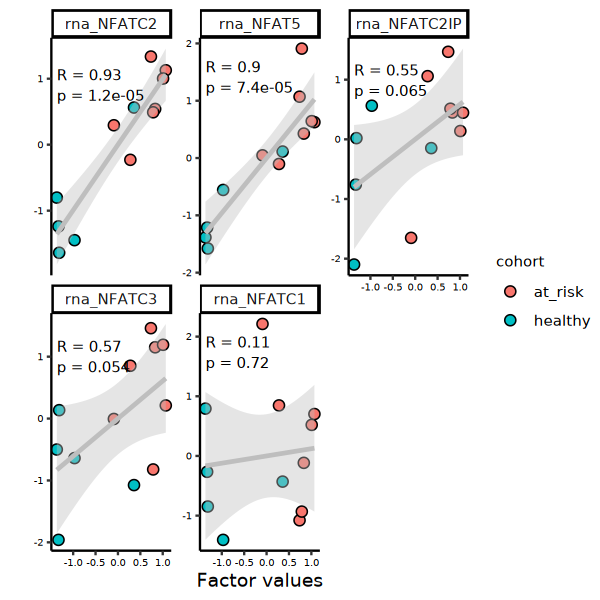

In [101]:
# check NFAT gene expression
# factor1_rna %>%  filter(str_detect(feature,'NFAT|FOXP3'))

# c('rna_STAT3',  'rna_NFATC3', 'rna_BATF') %in% weight$feature
plot_data_scatter(model,
  factor = 1,
  features = factor1_rna %>% filter(str_detect(feature, "NFAT|FOXP3")) %>% pull(feature) %>% as.character(),
  view = "rna", color_by = "cohort"
)
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_rna_correlation_cohort_NFATs.png")),
  width = 8, height = 4
)

In [102]:
# change the row names for plotting
rownames(model@data$rna$single_group) <- rownames(model@data$rna$single_group) %>% str_remove("rna_")

### Plot Fig 5D

In [103]:
# plot heatmap results for deg psudobulk
PlotDegHeatmap <- function(pseudo, genes, gene_meta = NULL, genes_hightlight = NULL,
                           assay = "normalized_counts", celltype_col,
                           celltype_colors = cluster_colors, batch_colors = cluster_colors_ext, scale = TRUE) {
  require("ComplexHeatmap")

  # set up the data matrix
  gex_matrix <- assay(pseudo, assay)[genes, ] %>% as.matrix()

  # set up the column annotation
  metadata <- colData(pseudo) %>% as.data.frame()
  # set up column annotation
  col_anno <- rowAnnotation(
    df = metadata %>% dplyr::select(c(status)) %>%
      as.data.frame(),
    col = list(status = c("CON2" = con_ari_colors[1], "ARI" = con_ari_colors[2])),
    annotation_legend_param =
      list(
        status = list(direction = "horizontal")
      )
  )
  # set up row annotation - gene labels at the right side
  if (!is.null(genes_hightlight)) {
    if (!all(genes_hightlight %in% genes)) {
      (stop("gene(s) to hightlight are not in the deg list."))
    } else {
      gene_index_tb <- tibble("index" = 1:length(rownames(gex_matrix)), gene = rownames(gex_matrix))
      gene_hightlight_index <- gene_index_tb %>%
        filter(gene %in% gene_hightlight) %>%
        pull(index)
      hightlight_labels <- gene_index_tb %>%
        filter(gene %in% gene_hightlight) %>%
        pull(gene)
      genename_anno <- rowAnnotation(foo = anno_mark(
        at = gene_hightlight_index,
        labels = hightlight_labels, gpar(fontsize = 12)
      ))
    }
  } else {
    (genename_anno <- NULL)
  }
  set.seed(1221)
  if (scale) (gex_matrix <- t(scale(t(gex_matrix))))

  p1 <- ComplexHeatmap::Heatmap(gex_matrix %>% t(),
    left_annotation = col_anno,
    cluster_rows = TRUE,
    col = colorRampPalette(c(nejm_color[2], "white", nejm_color[1]))(100),
    row_names_max_width = unit(10, "cm"),
    #    left_annotation = row_anno,
    right_annotation = genename_anno, #  column_names_rot = 45,
    show_column_names = TRUE, show_row_names = TRUE,
    column_names_gp = gpar(fontsize = 12),
    row_names_gp = gpar(fontsize = 12),
    heatmap_legend_param = list(
      title = "Scaled\nexpression", title_gp = gpar(fontsize = 12),
      legend_height = unit(6, "cm"), direction = "horizontal"
    )
  )
  return(p1)
}

In [104]:
colData(cd4na_rna_psudo)$cohort %>% unique()
colData(cd4na_rna_psudo)$status <- factor(if_else(colData(cd4na_rna_psudo)$cohort == "at_risk", "ARI", "CON2"),
  levels = c("CON2", "ARI")
)
colData(cd4na_rna_psudo)$status %>% unique()

[1] Healthy at_risk
Levels: Healthy at_risk

[1] CON2 ARI 
Levels: CON2 ARI

In [105]:
# specify tcr and calsium related genes
tcr_gene <- c(
  "VAV1", "GRB2", "GRAP2", "NFATC2", "NFAT5", "CBL",
  "CARD11", "LCK", "IKBKB", "CD4", "PIK3R1", "MALT1",
  "RAF1", "SOS1", "NCK2", "LCP2", "LAT", "NCK1", "RASGRP1", "MAP2K1",
  "PTPRC", "NFATC3", "MAP3K7", "PPP3CC", "PPP3CA", "GSK3B", "PPP3CC", "PLCG2", "PPP3CA", "CABIN1", "STIM1", "STIM2",
  "CSNK1A1", "LCK", "CD4", "NFATC1",
  "NFATC2IP"
) %>% unique()

In [109]:
# plot the gene heatmap in horizontal
pdf(file.path(fig_path, paste0(proj_name, "_facoter1_rna_tcr_ca_heatmap.pdf")),
  width = 6, height = 4
)
p1 <- PlotDegHeatmap(cd4na_rna_psudo, genes = tcr_gene)
draw(p1, heatmap_legend_side = "top")
dev.off()

pdf 
  2

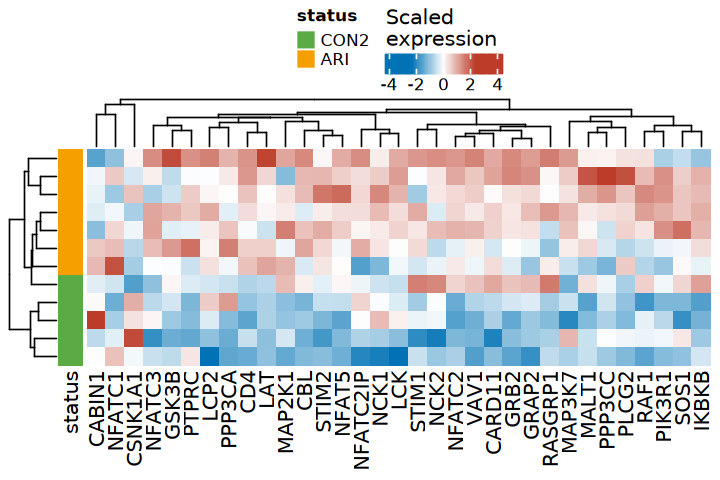

In [110]:
options(repr.plot.width = 6, repr.plot.height = 4)
draw(p1, heatmap_legend_side = "top")

In [133]:
## output the gene expression matrix
tcr_gex <- assay(cd4na_rna_psudo, "normalized_counts")[tcr_gene, ]
# get sample id
sample_ids <- meta_data %>%
  mutate(sample = factor(sample, levels = colData(cd4na_rna_psudo)$subject_id)) %>%
  arrange(sample)
stopifnot(sample_ids$sample == colData(cd4na_rna_psudo)$subject_id)
colnames(tcr_gex) <- sample_ids %>% pull(sample.sampleKitGuid)

In [138]:
tcr_gex %>%
  as_tibble(rownames = "gene") %>%
  write_csv(file.path(output_path, "TableS36_MOFA_CD4na_rna_f1_tcr_gex.csv"))

## check ADT


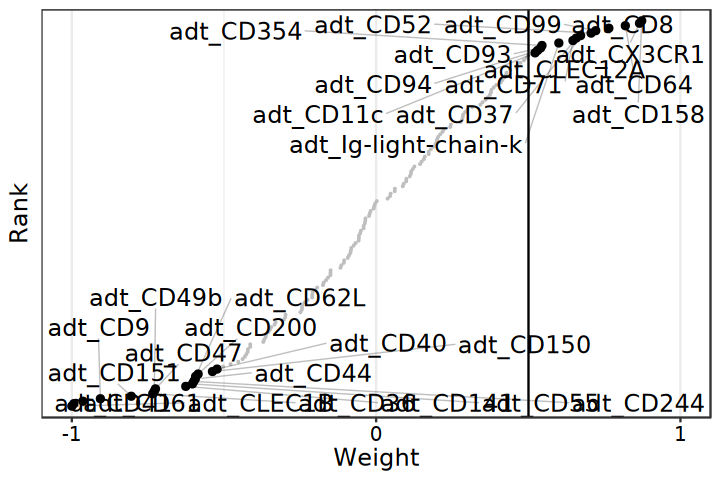

In [111]:
# check the Natural cutoff for tf
p1 <- plot_weights(model,
  view = "adt",
  factor = 1,
  nfeatures = 30, # Number of features to highlight
  scale = T, # Scale weights from -1 to 1
  abs = F # Take the absolute value?
)
p1 + geom_vline(xintercept = 0.5)
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_adts.png")),
  width = 5, height = 5
)

In [112]:
factor1_adt <- weight %>%
  filter(factor == "Factor1" & view == "adt") %>%
  mutate(direction = if_else(value > 0, "healthy", "at-risk")) %>%
  arrange(desc(abs(value)))
factor1_adt_sel <- factor1_adt %>%
  group_by(direction) %>%
  slice_max(order_by = abs(value), n = 25)
factor1_adt_sel %>%
  arrange(desc(value)) %>%
  head(20)

feature,factor,value,view,direction
<fct>,<fct>,<dbl>,<fct>,<chr>
adt_CD158,Factor1,0.7261817,adt,healthy
adt_CX3CR1,Factor1,0.7200784,adt,healthy
adt_CD64,Factor1,0.6813378,adt,healthy
adt_CD8,Factor1,0.6362790,adt,healthy
adt_CD99,Factor1,0.6003941,adt,healthy
adt_CD52,Factor1,0.5877974,adt,healthy
adt_CLEC12A,Factor1,0.5589985,adt,healthy
adt_CD37,Factor1,0.5471196,adt,healthy
adt_CD71,Factor1,0.5381499,adt,healthy


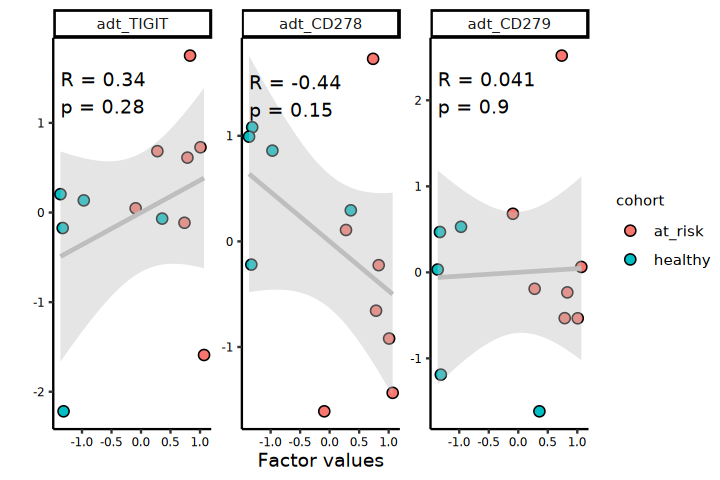

In [113]:
# check exhustion
p1 <- plot_data_scatter(model,
  factor = 1,
  features = c("adt_TIGIT", "adt_CD278", "adt_CD279"),
  view = "adt", color_by = "cohort"
)
# p2 <- plot_data_scatter(model, factor=1,
#                   features = c('rna_TIGIT', 'rna_HAVCR2', 'adt_PDCD1'),
#                         view='rna', color_by='cohort')
# cowplot::plot_grid(p1, p2, nrow = 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_adt_correlation_cohort_cd278_cd279_TIGIT.png")),
  width = 9, height = 3
)

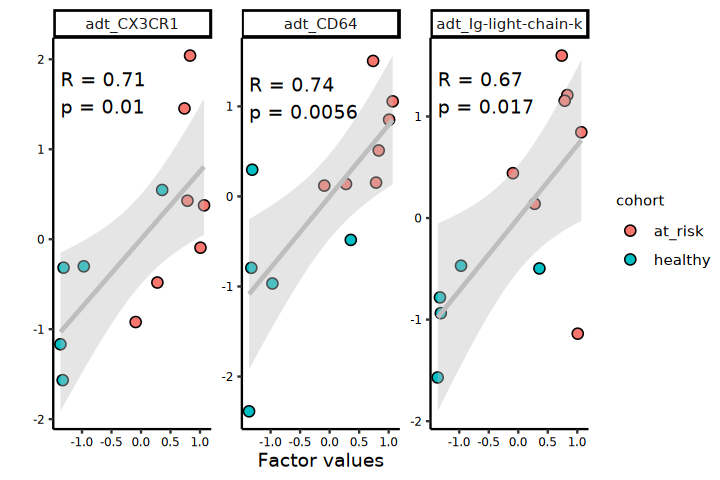

In [114]:
plot_data_scatter(model,
  factor = 1, features = c("adt_CX3CR1", "adt_CD64", "adt_Ig-light-chain-k"),
  view = "adt", color_by = "cohort"
)
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_adt_correlation_cohort_CX3CR1_fc.png")),
  width = 8, height = 4
)

pdf 
  2

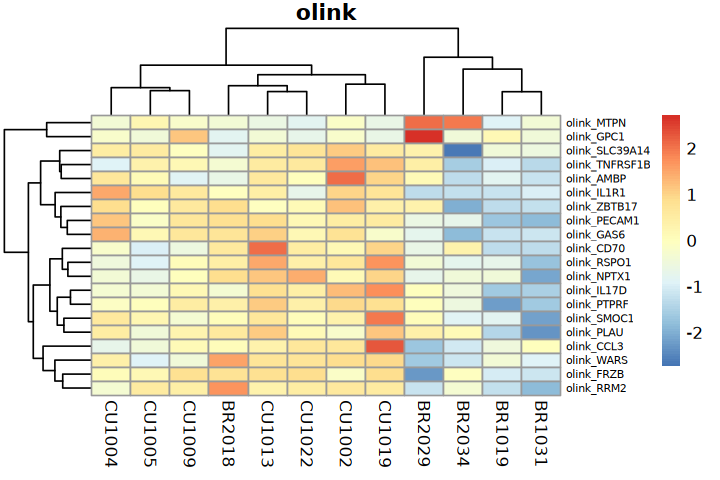

In [115]:
p1 <- plot_data_heatmap(model, # max.value = 3,
  view = "olink",
  factor = 1, main = "olink", fontsize_row = 6,
  features = 20, denoise = FALSE,
  cluster_rows = TRUE, cluster_cols = TRUE,
  show_rownames = TRUE, show_colnames = TRUE,
  scale = "row"
)
png(file.path(fig_path, paste0(proj_name, "_facoter1_olink_top20_heatmap.png")),
  units = "in", res = 300, width = 5, height = 5
)
print(p1)
dev.off()

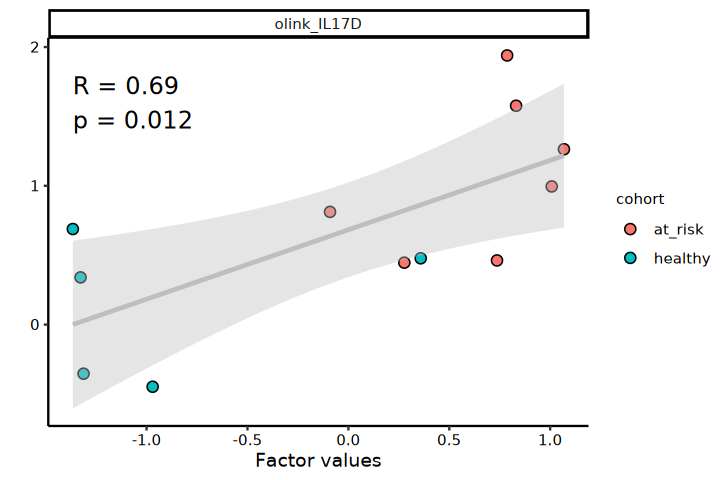

In [116]:
plot_data_scatter(model,
  factor = 1, features = c("olink_IL17D"),
  view = "olink", color_by = "cohort"
)
ggsave(file.path(fig_path, paste0(proj_name, "_facoter1_olink_correlation_cohort_IL17D.pdf")),
  width = 5, height = 4
)

In [117]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
 [1] grid      stats4    parallel  stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] ComplexHeatmap_2.22.0       hise_2.16.0                
 [3] SingleCellExperiment_1.28.0 SummarizedExperiment_1.36.0
 [5] Biobase_2.66.0              GenomicRanges_1.58.0       
 [7] GenomeInfoDb_1.42.0         IRanges_2.40.0             
 [9] S4Vectors_0.44.0            BiocGene